# Class Notes: Linear Regression, Part 2 (17 June 2026)

Topics covered:
1. Multicollinearity: what it is, why we care, how to detect it
2. Remedies for multicollinearity
3. The bias variance tradeoff
4. Regularization
5. Ridge regression (L2)
6. LASSO regression (L1)
7. Ridge vs LASSO

---

In [1]:

# Setup for this notebook
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
np.random.seed(1)


## 1. Multicollinearity

Part 1 ended on the dummy variable trap, which is one special case of a bigger problem that shows up whenever input features are related to each other.

**Multicollinearity is when two or more independent variables are strongly correlated with each other, so they carry overlapping information.**

Plainly: if two of your input columns move together almost perfectly, the model cannot tell which one is actually responsible for the effect, so it gets confused about their individual coefficients.

```
Clean features (good):        Collinear features (bad):
x1 . . . . .                  x1 and x2 rise together
x2 . . . . .   independent    x1 /       the model cannot
                              x2 /       separate their effects
```

A quick everyday picture: if you try to predict weight from both "height in cm" and "height in inches," those two columns are the same information twice. The model has no way to split the credit between them.

### Why should we care

The predictions can still be fine, but the coefficients become unreliable:

- Coefficient values swing wildly and can even flip sign with a tiny change in the data.
- Standard errors blow up, so p values get large and useful features look insignificant.
- The inference use of regression (reading each coefficient as an effect) is no longer trustworthy.

### Detection

**The Variance Inflation Factor (VIF) measures how much a feature's variance is inflated because it can be predicted from the other features.**

```
VIF for feature j = 1 / (1 - R_j^2)

where R_j^2 is the R squared from regressing feature j on all the other features.
```

Reading VIF:
- VIF around 1: the feature is independent of the others, all good.
- VIF above 5: getting worrying.
- VIF above 10: serious multicollinearity, act on it.

The logic: if the other features can already predict feature j well (high `R_j^2`), then j is redundant and the denominator `1 - R_j^2` gets tiny, so VIF explodes.

---

In [2]:
# detecting multicollinearity with VIF
# build 3 features: x2 is almost a copy of x1 (collinear), x3 is independent
n = 200
x1 = np.random.normal(0, 1, n)
x2 = x1 + np.random.normal(0, 0.05, n)   # nearly identical to x1
x3 = np.random.normal(0, 1, n)
X = np.column_stack([x1, x2, x3])

def vif(X, i):
    others = [j for j in range(X.shape[1]) if j != i]
    r2 = LinearRegression().fit(X[:, others], X[:, i]).score(X[:, others], X[:, i])
    return 1 / (1 - r2)

for i, name in enumerate(["x1", "x2", "x3"]):
    print(f"VIF({name}) = {vif(X, i):8.2f}")
print("\nx1 and x2 have huge VIFs (they carry the same information); x3 is near 1 and clean")

VIF(x1) =   310.70
VIF(x2) =   310.66
VIF(x3) =     1.01

x1 and x2 have huge VIFs (they carry the same information); x3 is near 1 and clean


## 2. Remedies for Multicollinearity

Once detected, the usual fixes are:

- **Drop one of the correlated features.** If height in cm and height in inches are both present, keep one.
- **Combine them** into a single feature (for example an average or a ratio, or a PCA component).
- **Use regularization** (Ridge in particular), which keeps all the features but shrinks the coefficients so they stop swinging wildly.

That last remedy is the bridge to the rest of today's notes.

---

## 3. The Bias Variance Tradeoff

Before regularization we need to understand the problem it solves, which is the balance every model has to strike.

**Bias is the error from a model being too simple to capture the real pattern. Variance is the error from a model being so flexible that it fits the noise in the training data.**

Plainly: high bias means the model underfits (it misses the signal), high variance means the model overfits (it memorizes the sample and fails on new data).

```
Underfit (high bias)     Good fit              Overfit (high variance)
line too simple          balanced              curve chases every point
   .   .                    .   .                 .   .
 --------- .              _/ ` \_ .              /\ .  /\  .
   .   .                 .   .                  .  \/ .  \/
misses pattern           captures pattern       memorizes noise
```

The tradeoff: reducing bias (a more complex model) usually raises variance, and reducing variance (a simpler model) usually raises bias. The goal is the sweet spot in the middle that minimizes total error on unseen data. Regularization is a dial that trades a little bias for a big drop in variance.

---

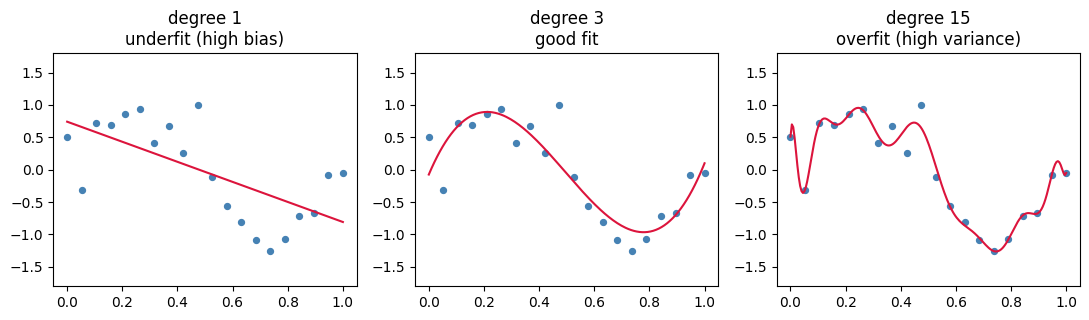

In [3]:
# bias variance shown with polynomial degrees on the same noisy data
from numpy.polynomial import polynomial as P
rng = np.random.default_rng(3)
xs = np.linspace(0, 1, 20)
true = np.sin(2 * np.pi * xs)
ys = true + rng.normal(0, 0.25, xs.size)
grid = np.linspace(0, 1, 200)

fig, ax = plt.subplots(1, 3, figsize=(11, 3.3))
for a, (deg, label) in zip(ax, [(1, "underfit (high bias)"),
                                (3, "good fit"),
                                (15, "overfit (high variance)")]):
    coef = np.polyfit(xs, ys, deg)
    a.scatter(xs, ys, s=18, color="steelblue")
    a.plot(grid, np.polyval(coef, grid), color="crimson")
    a.set_ylim(-1.8, 1.8); a.set_title(f"degree {deg}\n{label}")
plt.tight_layout(); plt.show()

## 4. Regularization

Plain linear regression only tries to minimize the error on the training data, which is exactly what lets it overfit and lets coefficients explode under multicollinearity.

**Regularization adds a penalty on the size of the coefficients to the cost function, so the model is discouraged from using large coefficients.**

Plainly: we tell the model "fit the data, but also keep your coefficients small," and a tuning knob called lambda controls how hard we push on that second goal.

```
Ordinary least squares cost:   sum( (y - yhat)^2 )
Regularized cost:              sum( (y - yhat)^2 )  +  lambda * (penalty on coefficients)
```

- lambda = 0: no penalty, you are back to ordinary regression.
- lambda large: heavy penalty, coefficients get squeezed hard toward zero, model gets simpler (more bias, less variance).

The two common penalties give the two methods below.

---

## 5. Ridge Regression (L2)

**Ridge regression adds an L2 penalty, the sum of the squared coefficients, to the cost.**

```
Ridge cost = sum( (y - yhat)^2 )  +  lambda * sum( b_j^2 )
```

Plainly: it squares each coefficient in the penalty, so large coefficients are punished a lot and small ones barely at all. The effect is that Ridge shrinks every coefficient toward zero but never exactly to zero.

Because it shrinks the correlated coefficients together instead of letting one blow up, Ridge is the natural regularization remedy for multicollinearity. It keeps all the features but tames them.

---

## 6. LASSO Regression (L1)

**LASSO (Least Absolute Shrinkage and Selection Operator) adds an L1 penalty, the sum of the absolute values of the coefficients.**

```
LASSO cost = sum( (y - yhat)^2 )  +  lambda * sum( |b_j| )
```

Plainly: it penalizes the absolute size of coefficients, and the shape of that penalty can drive some coefficients all the way to exactly zero.

That zeroing is the important part. A coefficient of exactly zero means the feature is dropped entirely, so LASSO does automatic feature selection while it fits. Give it a pile of features and it will keep the useful ones and switch the rest off.

---

## 7. Ridge vs LASSO

| Aspect | Ridge (L2) | LASSO (L1) |
|---|---|---|
| Penalty | sum of squared coefficients | sum of absolute coefficients |
| Shrinks coefficients | yes, toward zero | yes, toward zero |
| Sets coefficients to exactly zero | no | yes |
| Does feature selection | no | yes |
| Best when | many features all matter a bit, or multicollinearity | you suspect only a few features truly matter |

Plain summary: Ridge keeps everyone but quiets them down, LASSO fires the ones it does not need. When you are unsure, a blend of the two called Elastic Net gives you both behaviors, but the two above are the ones to know first.

---

In [4]:
# Ridge shrinks all coefficients; LASSO drives some to exactly zero
rng = np.random.default_rng(5)
n, p = 100, 8
Xr = rng.normal(0, 1, (n, p))
true_coef = np.array([5.0, -4.0, 3.0, 0, 0, 0, 0, 0])   # only 3 features matter
yr = Xr @ true_coef + rng.normal(0, 1, n)

ridge = Ridge(alpha=1.0).fit(Xr, yr)
lasso = Lasso(alpha=0.3).fit(Xr, yr)

print(f"{'feature':8}{'true':>8}{'ridge':>10}{'lasso':>10}")
for i in range(p):
    print(f"x{i+1:<7}{true_coef[i]:>8.1f}{ridge.coef_[i]:>10.3f}{lasso.coef_[i]:>10.3f}")
print(f"\nLASSO set {np.sum(np.isclose(lasso.coef_, 0))} coefficients to exactly zero (feature selection)")
print(f"Ridge set {np.sum(np.isclose(ridge.coef_, 0))} coefficients to exactly zero (it only shrinks)")

feature     true     ridge     lasso
x1           5.0     4.985     4.688
x2          -4.0    -4.097    -3.830
x3           3.0     2.960     2.602
x4           0.0     0.029     0.000
x5           0.0    -0.081     0.000
x6           0.0     0.149     0.000
x7           0.0    -0.066    -0.000
x8           0.0     0.123     0.000

LASSO set 5 coefficients to exactly zero (feature selection)
Ridge set 0 coefficients to exactly zero (it only shrinks)


## 8. Polynomial Regression

Everything so far fits a straight line (or flat plane). But many real relationships curve, and a straight line underfits them.

**Polynomial regression extends linear regression by adding powers of the input (x squared, x cubed, and so on) as extra features, so the model can fit a curve.**

Plainly: you keep ordinary linear regression, you just feed it x, x^2, x^3 as separate columns, and it bends to follow the data.

```
y = b0 + b1*x + b2*x^2 + b3*x^3 + ...
```

The important subtlety: this is still called linear regression, because "linear" refers to the coefficients being combined linearly, not to the shape of the curve. The model is linear in b0, b1, b2, it is only nonlinear in x.

Worked example on curved data `x = [1,2,3,4,5]`, `y = [2.2, 4.8, 9.1, 16.2, 24.8]` (roughly following x squared):

```
straight line fit:    R^2 = 0.9532   (cannot bend, underfits the curve)
quadratic fit:        y = 1.840 - 0.683*x + 1.057*x^2,  R^2 = 0.9997
```

(Verified in Python.) The quadratic term lets the model follow the curve almost perfectly, while the straight line leaves a visible gap.

### When to use Polynomial Regression

Use it when a scatter plot shows a clear curved trend that a straight line misses. The warning that comes with it: a high degree polynomial can wiggle through every training point and overfit badly, which is the high variance end of the bias variance tradeoff from earlier today. So the degree is a knob you tune, and low degrees (2 or 3) are usually enough. Regularization (Ridge or LASSO) is often layered on top to keep a high degree fit from going wild.

---

The through line for both days: linear regression is a clean, interpretable baseline, and most of the work is in reading the coefficients honestly (Part 1) and keeping them stable, trustworthy, and flexible enough to fit the real shape of the data (Part 2).

straight line: R^2 = 0.9532
quadratic    : y = 1.840 + -0.683 x + 1.057 x^2,  R^2 = 0.9997


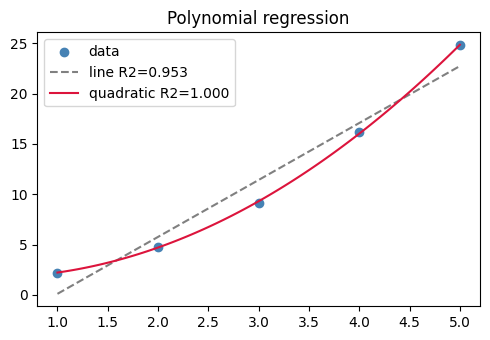

In [5]:
# a straight line underfits curved data; a quadratic follows it
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2.2, 4.8, 9.1, 16.2, 24.8])   # roughly x^2

# straight line
c1 = np.polyfit(x, y, 1)
r2_line = 1 - np.sum((y - np.polyval(c1, x))**2) / np.sum((y - y.mean())**2)
# quadratic
c2 = np.polyfit(x, y, 2)
r2_quad = 1 - np.sum((y - np.polyval(c2, x))**2) / np.sum((y - y.mean())**2)

print(f"straight line: R^2 = {r2_line:.4f}")
print(f"quadratic    : y = {c2[2]:.3f} + {c2[1]:.3f} x + {c2[0]:.3f} x^2,  R^2 = {r2_quad:.4f}")

grid = np.linspace(1, 5, 100)
plt.figure(figsize=(5, 3.5))
plt.scatter(x, y, color="steelblue", label="data")
plt.plot(grid, np.polyval(c1, grid), "--", color="gray", label=f"line R2={r2_line:.3f}")
plt.plot(grid, np.polyval(c2, grid), color="crimson", label=f"quadratic R2={r2_quad:.3f}")
plt.legend(); plt.title("Polynomial regression"); plt.tight_layout(); plt.show()